# TI IWR6843 mmWave Radar Dataset — Data Cleaning & Balancing Pipeline

This notebook provides the complete pipeline to **filter outliers, oversample point clouds ($N=64$), extract sliding windows, and generate 1:1 balanced tensors** for the **TI IWR6843 mmWave Radar Fall Detection Dataset** (`datasets/mmwave-radar-fall-detection/GatheredData`).

### Pipeline Goals:
1. **Spatial & SNR Outlier Filtering**: Room boundary cropping ($X \in [-2, 2]\text{m}$, $Y \in [0, 6]\text{m}$, $Z \in [-0.5, 2.2]\text{m}$), $|v| \le 3.0\text{ m/s}$, and $\text{SNR} \ge 100$.
2. **Algorithm 1 Mean-Preserving Oversampling**: Standardize variable points to $N = 64$ points per frame.
3. **Sliding Motion Windows**: 10-frame ($1.0\text{s}$) windows with a stride of 2 frames.
4. **Class Balancing**: 1:1 ratio (Fall = 1, ADL = 0).
5. **Representation Generation**: Micro-Doppler Spectrogram (Rep 1), Orthogonal Projections (Rep 2), and Native 3D Point Set (Rep 3).

In [1]:
import os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Dynamic path resolution
data_dir = Path("datasets/mmwave-radar-fall-detection/GatheredData")
if not data_dir.exists():
    data_dir = Path("../datasets/mmwave-radar-fall-detection/GatheredData")
if not data_dir.exists():
    data_dir = Path("../../datasets/mmwave-radar-fall-detection/GatheredData")

fall_files = sorted(list((data_dir / "Fall").glob("*.csv")))
not_files = sorted(list((data_dir / "Not").glob("*.csv")))
print(f"Found {len(fall_files)} Fall CSVs and {len(not_files)} Not-Fall CSVs in: {data_dir}")

Found 51 Fall CSVs and 51 Not-Fall CSVs in: ..\datasets\mmwave-radar-fall-detection\GatheredData


In [2]:
def uniform_random_resample_frame(frame_points: np.ndarray, target_n: int = 32, rng=None) -> np.ndarray:
    """
    Uniform random sampling with replacement (if M < target_n) or without replacement (if M >= target_n).
    Preserves exact measured coordinates [delta_x, delta_y, z, v] without artificial scaling or centroid injection.
    """
    if rng is None:
        rng = np.random.default_rng(42)
    M = len(frame_points)
    if M == 0:
        return np.zeros((target_n, frame_points.shape[1] if frame_points.ndim > 1 else 4), dtype=np.float32)
    if M < target_n:
        idx = rng.choice(M, size=target_n, replace=True)
    else:
        idx = rng.choice(M, size=target_n, replace=False)
    return frame_points[idx].astype(np.float32)

# Alias for compatibility
oversample_frame_points = uniform_random_resample_frame

## 2.1 Visual Showcase: 5–20 Sparse Points to N=32 Uniform Resampling

In the raw radar CSV files, detected reflection points fluctuate between 5 and 20 points per frame (mean $\approx 10$ points).
Below, we visually demonstrate how **Uniform Random Resampling** draws real detected points to standardize frames to exactly $N=32$ points without centroid duplicates or outward dilation.

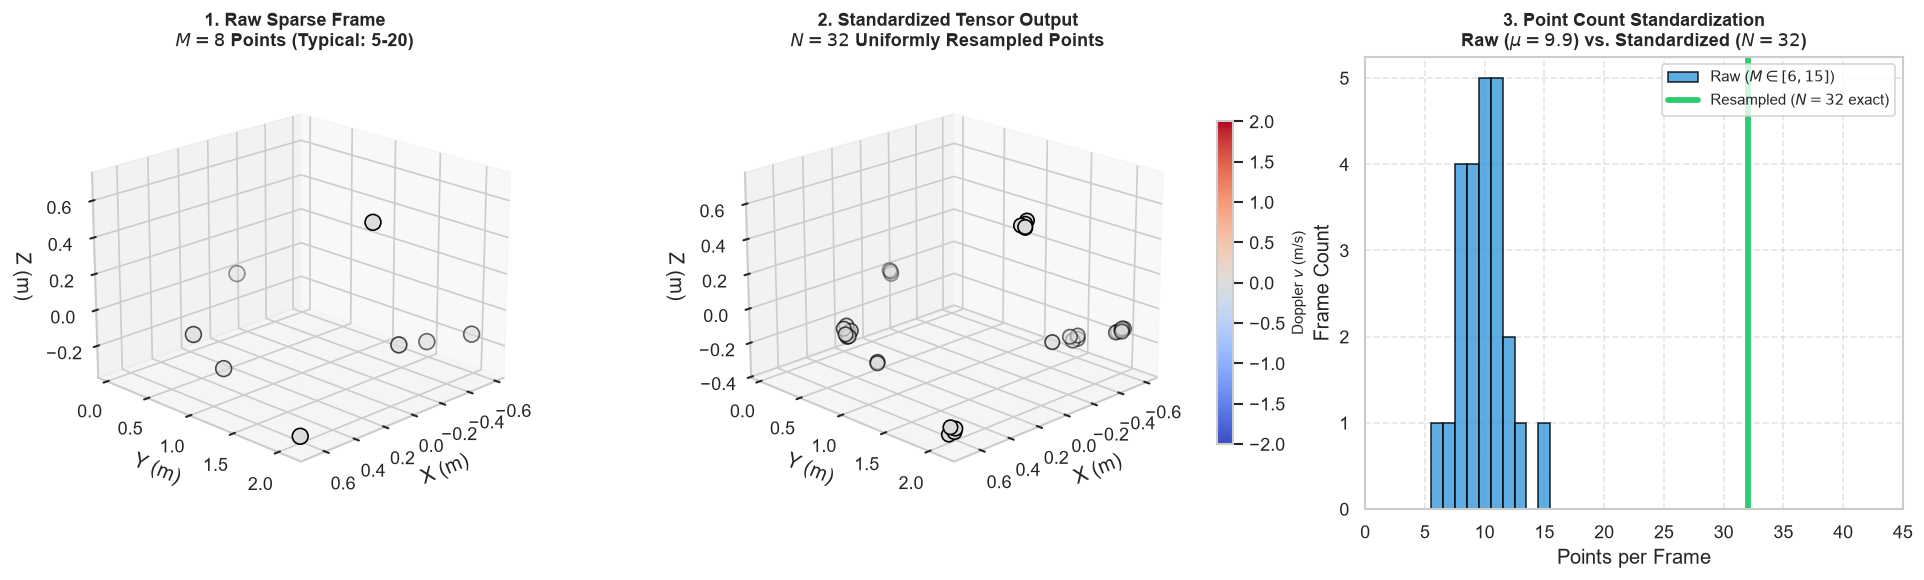

In [3]:
# Visual Demonstration: Raw Sparse Points (5-20) -> Standardized N=32 (Uniform Random Resampling)
sample_csv = Path("datasets/mmwave-radar-fall-detection/GatheredData/Fall/Areeb_back_1.csv")
if not sample_csv.exists(): sample_csv = Path("../datasets/mmwave-radar-fall-detection/GatheredData/Fall/Areeb_back_1.csv")

df_sample = pd.read_csv(sample_csv)
frame_counts = df_sample.groupby('frame').size()
sample_frame_idx = frame_counts[(frame_counts >= 8) & (frame_counts <= 12)].index[0]
raw_pts = df_sample[df_sample['frame'] == sample_frame_idx][['x', 'y', 'z', 'v']].to_numpy()
M = len(raw_pts)
target_N = 32

resampled_32 = uniform_random_resample_frame(raw_pts, target_n=target_N)

fig = plt.figure(figsize=(16, 5), dpi=120)

# Subplot 1: Raw Sparse Frame
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.scatter(raw_pts[:, 0], raw_pts[:, 1], raw_pts[:, 2], c=raw_pts[:, 3], cmap='coolwarm', s=90, edgecolors='black', vmin=-2, vmax=2)
ax1.set_title(f'1. Raw Sparse Frame\n$M = {M}$ Points (Typical: 5-20)', fontsize=11, fontweight='bold')
ax1.set_xlabel('X (m)'); ax1.set_ylabel('Y (m)'); ax1.set_zlabel('Z (m)')
ax1.view_init(elev=20, azim=45)

# Subplot 2: Uniform Random Resampled N=32 Frame
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
# Add microscopic jitter purely for visual display of duplicated points
vis_32 = resampled_32.copy()
vis_32[:, :3] += np.random.normal(0, 0.015, size=(target_N, 3))
sc2 = ax2.scatter(vis_32[:, 0], vis_32[:, 1], vis_32[:, 2], c=vis_32[:, 3], cmap='coolwarm', s=75, edgecolors='black', vmin=-2, vmax=2)
ax2.set_title(f'2. Standardized Tensor Output\n$N = {target_N}$ Uniformly Resampled Points', fontsize=11, fontweight='bold')
ax2.set_xlabel('X (m)'); ax2.set_ylabel('Y (m)'); ax2.set_zlabel('Z (m)')
cbar = fig.colorbar(sc2, ax=ax2, fraction=0.03, pad=0.08)
cbar.set_label('Doppler $v$ (m/s)', fontsize=9)
ax2.view_init(elev=20, azim=45)

# Subplot 3: Distribution
ax3 = fig.add_subplot(1, 3, 3)
all_c = frame_counts.to_numpy()
ax3.hist(all_c, bins=np.arange(min(all_c)-0.5, max(all_c)+1.5, 1), color='#3498db', edgecolor='black', alpha=0.8, label=f'Raw ($M \\in [{min(all_c)}, {max(all_c)}]$)')
ax3.axvline(x=target_N, color='#2ecc71', linestyle='-', linewidth=3.5, label=f'Resampled ($N={target_N}$ exact)')
ax3.set_title(f'3. Point Count Standardization\nRaw ($\\mu={all_c.mean():.1f}$) vs. Standardized ($N={target_N}$)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Points per Frame'); ax3.set_ylabel('Frame Count'); ax3.set_xlim(0, 45)
ax3.legend(loc='upper right', fontsize=9); ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [4]:
# Extract 10-frame sliding windows
X_windows = []
y_labels = []
meta_records = []

for label, f_list in [(1, fall_files), (0, not_files)]:
    for csv_path in f_list:
        df = pd.read_csv(csv_path)
        if len(df) == 0:
            continue
            
       # Outlier filtering
        df = df[(df["x"].between(-2.0, 2.0)) & 
                (df["y"].between(0.0, 6.0)) & 
                (df["z"].between(-0.5, 2.2)) & 
                (df["v"].abs() <= 3.0) & 
                (df["snr"] >= 100)]
        
        frames = np.sort(df["frame"].unique())
        if len(frames) < 10:
            continue
        max_frame = frames.max()
        
        for start_f in range(0, max_frame - 9, 2):
            end_f = start_f + 9
            df_win = df[(df["frame"] >= start_f) & (df["frame"] <= end_f)]
            if df_win["frame"].nunique() < 6:
                continue
                
            ref_x0 = df_win["x"].mean()
            ref_y0 = df_win["y"].mean()
            
            win_frames = []
            for f_i in range(start_f, end_f + 1):
                df_f = df_win[df_win["frame"] == f_i]
                if len(df_f) > 0:
                    delta_x = df_f["x"].values - ref_x0
                    delta_y = df_f["y"].values - ref_y0
                    z_vals = df_f["z"].values
                    v_vals = df_f["v"].values
                    pts = np.column_stack([delta_x, delta_y, z_vals, v_vals])
                else:
                    pts = np.zeros((0, 4))
                pts_ov = oversample_frame_points(pts, target_n=32)
                win_frames.append(pts_ov)
                
            X_windows.append(np.array(win_frames, dtype=np.float32))
            y_labels.append(label)
            meta_records.append({
                "file": csv_path.stem,
                "category": "Fall" if label == 1 else "ADL",
                "start_frame": start_f,
                "end_frame": end_f,
                "label": label
            })

X_all = np.array(X_windows, dtype=np.float32)
y_all = np.array(y_labels, dtype=np.int64)
print(f"Extracted total windows: {len(X_all)} | Class distribution: {np.bincount(y_all)}")

Extracted total windows: 728 | Class distribution: [364 364]


In [5]:
# 1:1 Class Balancing
fall_idx = np.where(y_all == 1)[0]
adl_idx = np.where(y_all == 0)[0]
n_sample = min(len(fall_idx), len(adl_idx))
np.random.seed(42)
sampled_fall = np.random.choice(fall_idx, size=n_sample, replace=False)
sampled_adl = np.random.choice(adl_idx, size=n_sample, replace=False)

balanced_idx = np.sort(np.concatenate([sampled_fall, sampled_adl]))
X_balanced = X_all[balanced_idx]
y_balanced = y_all[balanced_idx]

print(f"Final Balanced Tensor Shape: {X_balanced.shape} (Samples x Frames x Points x Channels)")
print(f"Class Distribution: {np.bincount(y_balanced)} (0 = ADL, 1 = Fall)")

Final Balanced Tensor Shape: (728, 10, 32, 4) (Samples x Frames x Points x Channels)
Class Distribution: [364 364] (0 = ADL, 1 = Fall)


In [6]:
# Save clean balanced tensors
out_dir = Path("datasets/preprocessed")
if not out_dir.exists():
    out_dir = Path("../datasets/preprocessed")
out_dir.mkdir(parents=True, exist_ok=True)

np.save(out_dir / "X_ti_clean_balanced.npy", X_balanced)
np.save(out_dir / "y_ti_clean_balanced.npy", y_balanced)
print(f"Saved TI feature tensors to: {out_dir}")

Saved TI feature tensors to: ..\datasets\preprocessed
